## Νευρωνικά Δίκτυα - Βαθιά Μάθηση: Εργασία 2
##### Δημήτριος Μουταφτσίδης , 9920 (ΤΗΜΜΥ)
##### moutdimi@ece.auth.gr
##### 23/12/25

In [1]:
import numpy as np

import torch
import torchvision
from torchvision import datasets

import matplotlib.pyplot as plt

import random as rnd
import time
from pprint import pprint
import os

from sklearn.metrics import confusion_matrix , classification_report , accuracy_score
from sklearn.svm import LinearSVC , SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import pandas as pd

In [2]:
configuration = {
    
    "root" : r"C:\Users\dimit\Desktop\Νευρωνικά\Εργασία 2" ,
}

In [3]:
training_set = datasets.CIFAR10(
    root = configuration["root"],
    #Designates data as Training.
    train = True,
    download = True,
    transform = None
)

test_set = datasets.CIFAR10(
    root = configuration["root"],
    #Designates Data as Testing.
    train = False,
    download = True,
    transform = None
)

#### 1. Συνάρτηση Sample
Επιστρέφει ένα υποσύνολο των εικόνων. Το υποσύνολο αυτό είναι Stratified. Δηλαδή η αναλογία μεταξύ του πλήθους των κλάσεων διατηρείται. Αξιοποιούμε την γνώση μας για την CIFAR-10 σχετικά με την ισάριθμη κατανομή κλάσεων. Δεν χρειάζεται να υπολογίσουμε την συχνότητα εμφάνισης της κάθε μίας.

In [25]:
def Sample(images , labels , samples , random_state = 0):

    #Every class occupies one tenth of the samples. It is the responsibility of the user to provide a number divisible by 10.
    samples_per_class = samples // 10
    labels = np.asarray(labels)
    #Setting a random seed for reproducability.
    rng = np.random.default_rng(random_state)

    #Pre-allocate indices table.
    indices = []

    #Loop over class indices 0-9.
    for i in range(10):
        #Find the indices of the i-th class.
        class_indices = np.where(labels == i)[0]
        #Use random.choice to randomly select some of them.
        chosen = rng.choice(class_indices , size = samples_per_class , replace = False)
        #Append results to indices table.
        indices.append(chosen)
    
    #Join and shuffle indices array.
    indices = np.concatenate(indices)
    rng.shuffle(indices)

    #Extract selected images and their labels.
    sampled_images = images[indices]
    sampled_labels = labels[indices]

    return sampled_images , sampled_labels

#### 2. Συνάρτηση Grid_Search
Είναι η βασική συνάρτηση υλοποίησης των πειραμάτων για επιλογή παραμέτρων. Εκπαιδεύει με την χρήση Cross Validation και εκτελέι Grid Search σε σύνολο δοσμένων παραμέτρων. Συγκεντρώνει τα αποτελέσματα σε Pandas Dataframe και τα επιστρέφει.

In [28]:
def Grid_Search(images , labels , setups , k = 3 , pca_components = 0.90):

    #Call StratifiedKFold with set seed. This is the Cross Validation module
    cv = StratifiedKFold(n_splits = k , shuffle = True , random_state = 0)

    #Preallocate.
    dataframes = []
    best_estimator = None
    best_score = float("-inf")

    #Loop over setup. This is the first Grid Search level. Setup is a list of dictionaries which may in turn contain lists as elements.
    for setup in setups:

        #Extract setup name , the estimator and the parameter grid.
        name = setup["Name"]
        estimator = setup["Estimator"]
        params = setup["Parameter_Grid"]

        #Standard Scaler is a default step so it is done regardless.
        steps = [("scaler" , StandardScaler())]

        #Append PCA to steps if non-zero value is given.
        if pca_components != 0:
            steps.append(("PCA" , PCA(n_components = pca_components)))
        #Append the estimator as well. 
        steps.append(("clf" , estimator))

        #Sickitlearn's Pipeline() method takes the list of tuples and automatically turns them to a fully working, machine readable pipeline.
        working_pipeline = Pipeline(steps)

        #The built-in GridSearchCV module performs the inner Grid Search operation. It handles one of the setups provided in the setups list.
        grid_search = GridSearchCV(estimator = working_pipeline , 
                                   param_grid = params , 
                                   scoring = "accuracy" , 
                                   cv = cv ,
                                   n_jobs = -1 , 
                                   verbose = 2 , 
                                   return_train_score = True)
        #grid_search is now a callable. It has methods like .fit and .cv_results_. We fit the training data and store the results in the dataframe.
        grid_search.fit(images , labels)

        #Automatic extraction of results in a neat format.
        dataframe = pd.DataFrame(grid_search.cv_results_)

        dataframe.insert(0 , "Setup_Name" , name)
        dataframe.insert(1 , "PCA_Components" , pca_components)

        #Append said dataframe to dataframes list.
        dataframes.append(dataframe)

        if grid_search.best_score_ > best_score:
            best_score = grid_search.best_score_
            best_estimator = grid_search.best_estimator_

    #Unify and sort all dataframes to one. We sort based on the mean_test_score column values.
    final_dataframe = pd.concat(dataframes , ignore_index = True)
    final_dataframe = final_dataframe.sort_values("mean_test_score" , ascending = False).reset_index(drop = True)

    best = final_dataframe.iloc[0]

    return final_dataframe , best_estimator , best

#### 3.Συνάρτηση Grayscale
Πολύ απλή συνάρτηση. Επιστρέφει τις εικονες σε μορφή Grayscale μέσω της καθιερωμένης μαθηματικής σχέσης.

In [31]:
def Grayscale(images):

    #The fourth dimension of the images array essentially contains the RBG values.
    images_grayscale = (0.299 * images[: , : , : , 0] +
                        0.587 * images[: , : , : , 1] +
                        0.114 * images[: , : , : , 2]
                        ).astype(np.float32)
    #A 3-D array is returned.
    return images_grayscale

#### 4. Συνάρτηση Frequency_Content
Δέχεται Grayscale εικόνες και επιστρέφει το Log Magnitude του μετασχηματισμού Fourier τους. 

In [34]:
def Frequency_Content(images , log = True , shift = True):

    #Get images array dimensions. N images of dimensions HxW.
    N , H , W = images.shape

    #Preallocate the FT array for efficiency.
    fourier_transform = np.empty((N , H , W) , dtype = np.float32)

    #Enumerate through images.
    for index , image in enumerate(images):

        #Apply the Fast 2D Fourier Transform to the image.
        ft = np.fft.fft2(image)

        #Shift if necessary.
        if shift:
            ft = np.fft.fftshift(ft)

        #Keep the magnitude.
        magnitude = np.abs(ft)

        #Log it to avoid scaling issues.
        if log:
            magnitude = np.log1p(magnitude)

        #Store value to FT array.
        fourier_transform[index] = magnitude


    return fourier_transform

#### Πείραμα 6. 
Κάτω φαίνεται το setup του πειράματος 6. Τα προηγούμενα έγιναν με ακριβώς αυτό τον τρόπο, τροποποιώντας ανάλογα τις εικόνες και τις τιμές στο setups. Για τα πειράματα στο FT πχ, πρέπει να καλέσουμε και τις συναρτήσεις Grayscale και Frequency_Content με αυτή την σειρά. 

In [8]:
training_images = training_set.data.astype(np.float32) / 255.0
training_labels = np.array(training_set.targets)

print(training_images.shape)
print(training_labels.shape)
print(type(training_images))

#Here we sample for 20.000 images.
images , labels = Sample(training_images , training_labels , 20000)

images = images.reshape(images.shape[0] , -1)


(50000, 32, 32, 3)
(50000,)
<class 'numpy.ndarray'>


In [17]:
setup_rbf = {
    "Name" : "RBF_Kernel" , 
    "Estimator" : SVC(kernel = "rbf") , 
    "Parameter_Grid" : {"clf__C" : [4.0 , 5.0 , 7.0 , 10.0] , "clf__gamma" : ["scale" , 1e-3 , 1e-4] , }
}

#Example usage: setup_poly = {"Name" : "RBF_Kernel" , 
    #"Estimator" : SVC(kernel = "rbf") , 
    #"Parameter_Grid" : {"clf__C" : [4.0 , 5.0 , 7.0 , 10.0] , "clf__degree" : [2, 3] , etc etc }}
#Carefull: use of clf__ prefix is necessary. IDK why.
setups = [setup_rbf]

df , best_estimator , best_row = Grid_Search(images , labels , setups , pca_components=0.9 , k = 5)

out_file = "Plain_SVM_RBF.xlsx"
#Write file to Excel.
with pd.ExcelWriter(out_file, engine="openpyxl", mode="w") as writer:
    df.to_excel(writer, sheet_name="plain_pixels", index=False)

print("Saved:", out_file)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Saved: Plain_SVM_RBF.xlsx


#### Final Runs
Ακολουθεί ο κώδικας των δύο πειραμάτων για ολόκληρο το dataset και η αξιολόγηση στο training set.

In [17]:
test_images = test_set.data.astype(np.float32) / 255.0
test_labels = np.array(test_set.targets)

training_images = training_images.reshape(training_images.shape[0], -1)
test_images  = test_images.reshape(test_images.shape[0], -1)

model_pca = Pipeline([
    ("scaler" , StandardScaler()),
    ("pca", PCA(n_components=0.90)),
    ("clf", SVC(kernel="rbf", C=5.0, gamma="scale"))])

start = time.time()
model_pca.fit(training_images, training_labels)
training_time = time.time() - start

start = time.time()
predictions_1 = model_pca.predict(test_images)
test_time = time.time() - start

acc = accuracy_score(test_labels, predictions_1)
cm = confusion_matrix(test_labels, predictions_1)
report = classification_report(test_labels, predictions_1)

print("Train time (s):", training_time)
print("Test time (s):", test_time)
print("Test accuracy:", acc)
print("Confusion matrix:\n", cm)
print("Classification report:\n", report)

Train time (s): 353.5165400505066
Test time (s): 58.9834303855896
Test accuracy: 0.5647
Confusion matrix:
 [[659  28  50  22  28  17  21  21 111  43]
 [ 31 691  14  32  13  16  13  18  54 118]
 [ 73  23 449  82 134  68  87  53  17  14]
 [ 32  25  95 384  63 174 116  45  21  45]
 [ 39   7 150  76 494  39 106  56  17  16]
 [ 25  12  75 190  62 474  60  62  24  16]
 [ 16  16  88  88  95  35 628  11  10  13]
 [ 33  21  53  65  85  81  20 586  10  46]
 [ 97  57  18  32  21  14  10  12 690  49]
 [ 53 158  16  41  13  19  16  34  58 592]]
Classification report:
               precision    recall  f1-score   support

           0       0.62      0.66      0.64      1000
           1       0.67      0.69      0.68      1000
           2       0.45      0.45      0.45      1000
           3       0.38      0.38      0.38      1000
           4       0.49      0.49      0.49      1000
           5       0.51      0.47      0.49      1000
           6       0.58      0.63      0.60      1000
     

In [23]:
model_no_pca = Pipeline([
    ("scaler" , StandardScaler()),
    ("clf", SVC(kernel="rbf", C=5.0, gamma="scale"))])

start = time.time()
model_no_pca.fit(training_images, training_labels)
training_time = time.time() - start

start = time.time()
predictions_2 = model_no_pca.predict(test_images)
test_time = time.time() - start

acc = accuracy_score(test_labels, predictions_2)
cm_2 = confusion_matrix(test_labels, predictions_2)
report = classification_report(test_labels, predictions_2)

print("Train time (s):", training_time)
print("Test time (s):", test_time)
print("Test accuracy:", acc)
print("Confusion matrix:\n", cm_2)
print("Classification report:\n", report)

Train time (s): 5783.787525892258
Test time (s): 1368.8668150901794
Test accuracy: 0.5732
Confusion matrix:
 [[659  28  51  26  26  15  20  22 105  48]
 [ 37 683  13  29  14  15  13  20  46 130]
 [ 71  23 476  91 120  53  82  47  20  17]
 [ 29  30  96 404  63 167  99  45  23  44]
 [ 47  11 160  67 481  46  92  58  23  15]
 [ 31  11  72 207  68 470  62  46  17  16]
 [ 15  20  87  97  92  32 627  11   9  10]
 [ 36  23  60  73  72  73  12 597   9  45]
 [ 81  63  15  30  20  11  11  13 707  49]
 [ 49 149  13  39  11  18  15  29  49 628]]
Classification report:
               precision    recall  f1-score   support

           0       0.62      0.66      0.64      1000
           1       0.66      0.68      0.67      1000
           2       0.46      0.48      0.47      1000
           3       0.38      0.40      0.39      1000
           4       0.50      0.48      0.49      1000
           5       0.52      0.47      0.49      1000
           6       0.61      0.63      0.62      1000
   

#### 5. Συνάρτηση Plot_CM
Αυτούσια από Εργασία 1.

In [25]:
def Plot_CM(cm , class_names):

    fmt = "d"
    
    plt.figure(figsize = (8 , 8))
    plt.imshow(cm , interpolation = "nearest" , cmap = "Blues")
    plt.title("Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks , class_names , rotation = 45)
    plt.yticks(tick_marks , class_names)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            plt.text(
                j, i,
                format(value, fmt),
                ha="center", va="center",
                color="white" if value > thresh else "black"
            )
    
    
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

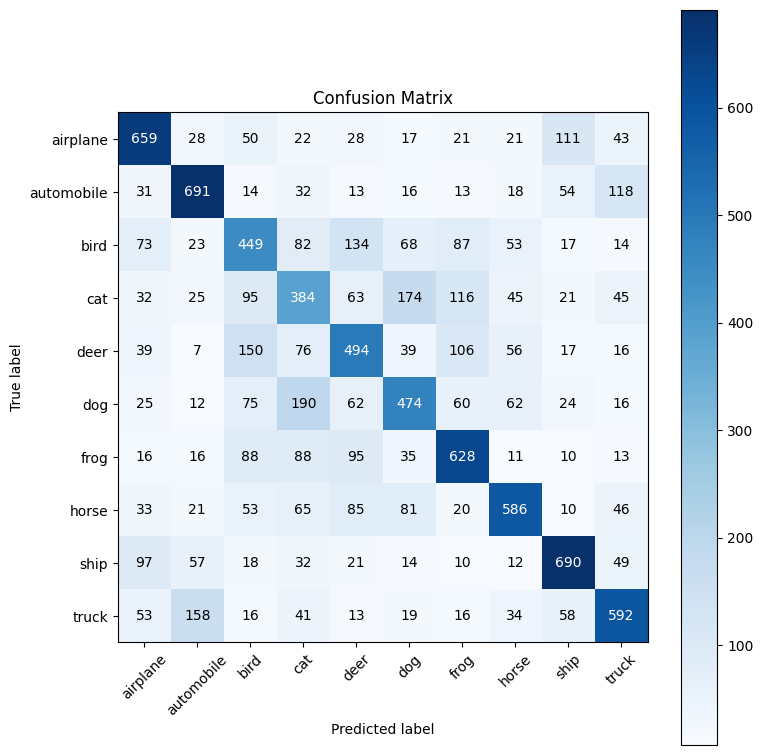

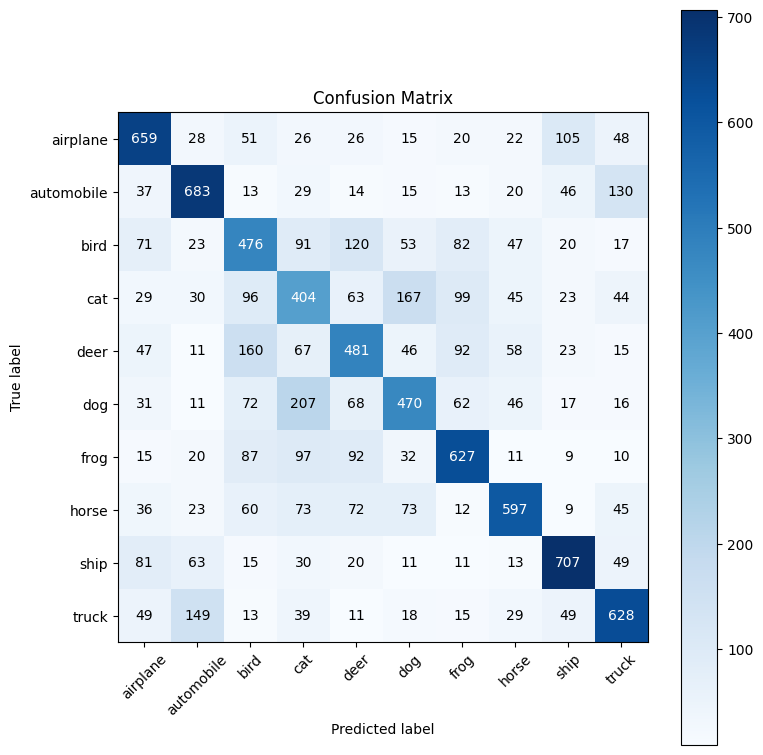

In [29]:
Plot_CM(cm , training_set.classes)
Plot_CM(cm_2 , training_set.classes)

#### 6. Συνάρτηση Show_Images
Βρίσκει σωστές και λανθασμένες ταξινομήσεις ανάλογα με το correct Flag Και τις εκτυπώνει.

In [49]:
CIFAR10_CLASSES = training_set.classes

def Show_Images(images, labels , predictions , class_names=CIFAR10_CLASSES,
                        n=10 , correct = True , random_state = 0, title = None):

    labels = np.asarray(labels)
    predictions = np.asarray(predictions)

    if correct:
        indices = np.where(labels == predictions)[0]
        default_title = "Correctly classified examples"
    else:
        indices = np.where(labels != predictions)[0]
        default_title = "Misclassified examples"

    
    rng = np.random.default_rng(random_state)
    chosen = rng.choice(indices, size = n, replace = False)

    cols = 6
    rows = int(np.ceil(len(chosen) / cols))
    plt.figure(figsize=(2.4 * cols, 2.6 * rows))
    for i, j in enumerate(chosen, start=1):
        plt.subplot(rows, cols, i)
        img = images[j]

       
        plt.imshow(img)

        t = class_names[labels[j]]
        p = class_names[predictions[j]]
        plt.title(f"T: {t}\nP: {p}", fontsize=9)
        plt.axis("off")

    plt.suptitle(title if title else default_title, fontsize=14)
    plt.tight_layout()
    plt.show()

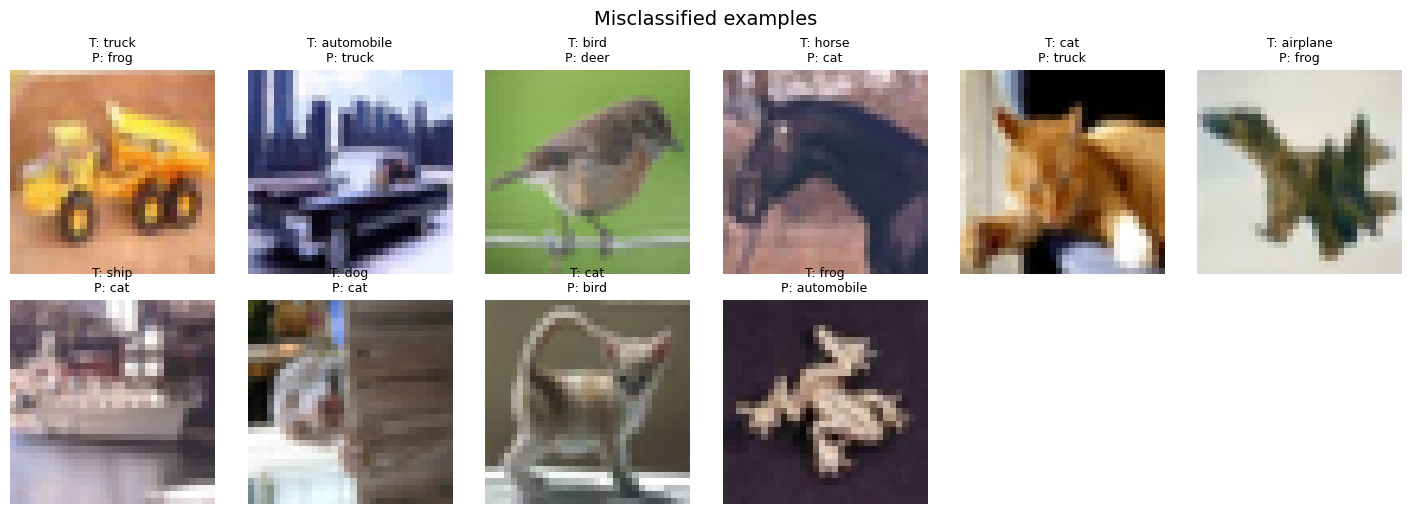

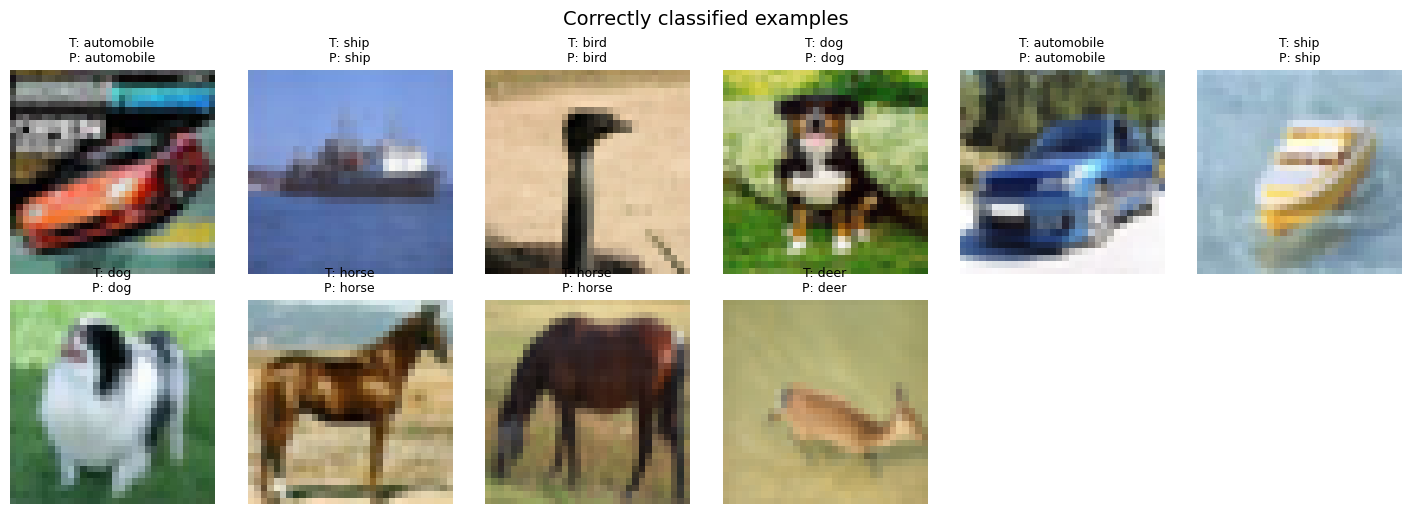

In [53]:
test_images_raw = test_set.data
Show_Images(test_images_raw , test_labels , predictions_1 , correct=False)
Show_Images(test_images_raw , test_labels , predictions_1 , correct=True)